# 🌍 Weather Trend Forecasting
### Data Science Assessment — PM Accelerator

> **PM Accelerator Mission:** Empowering the next generation of product managers through hands-on data science and analytics training. Building real-world skills to drive data-informed product decisions at scale.

---

## 1️⃣ Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Matplotlib is building the font cache; this may take a moment.


In [3]:
# Load data
DATA_PATH = "/Users/hardikarora/Desktop/Data_Science_assessment/data/GlobalWeatherRepository.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)}")
df.head()

Shape: (133318, 41)

Columns: ['country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'last_updated', 'temperature_celsius', 'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination']

Data Types:
country                             str
location_name                       str
latitude                        float64
longitude                       float64
timezone                            str
last_updated_epoch                int64

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


## 2️⃣ Data Preprocessing & Distributions

In [4]:
# Convert last_updated to datetime
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

# Basic stats
df.describe().T

Duplicate rows: 0


,count,mean,min,25%,50%,75%,max,std
latitude,133318.0,19.207034,-41.3,4.050075,17.25,40.4,64.15,24.417913
longitude,133318.0,21.966088,-175.2,-6.8361,23.2361,50.40555,179.22,65.787537
last_updated_epoch,133318.0,1745516451.281147,1715849100.0,1730710800.0,1745570700.0,1760342400.0,1775197800.0,17119922.381598
last_updated,133318,2025-04-24 19:49:55.717757,2024-05-16 01:45:00,2024-11-04 16:00:00,2025-04-25 03:07:30,2025-10-13 04:00:00,2026-04-03 19:30:00,NaN
temperature_celsius,133318.0,21.316548,-29.8,16.0,24.0,28.0,49.2,9.703496
temperature_fahrenheit,133318.0,70.371554,-21.6,60.8,75.2,82.4,120.6,17.466153
wind_mph,133318.0,8.027428,2.2,3.8,6.7,11.0,1841.2,7.247682
wind_kph,133318.0,12.922491,3.6,6.1,10.8,17.6,2963.2,11.660847
wind_degree,133318.0,168.915203,1.0,80.0,161.0,256.0,360.0,103.696235
pressure_mb,133318.0,1014.063787,947.0,1010.0,1014.0,1018.0,3006.0,10.411632


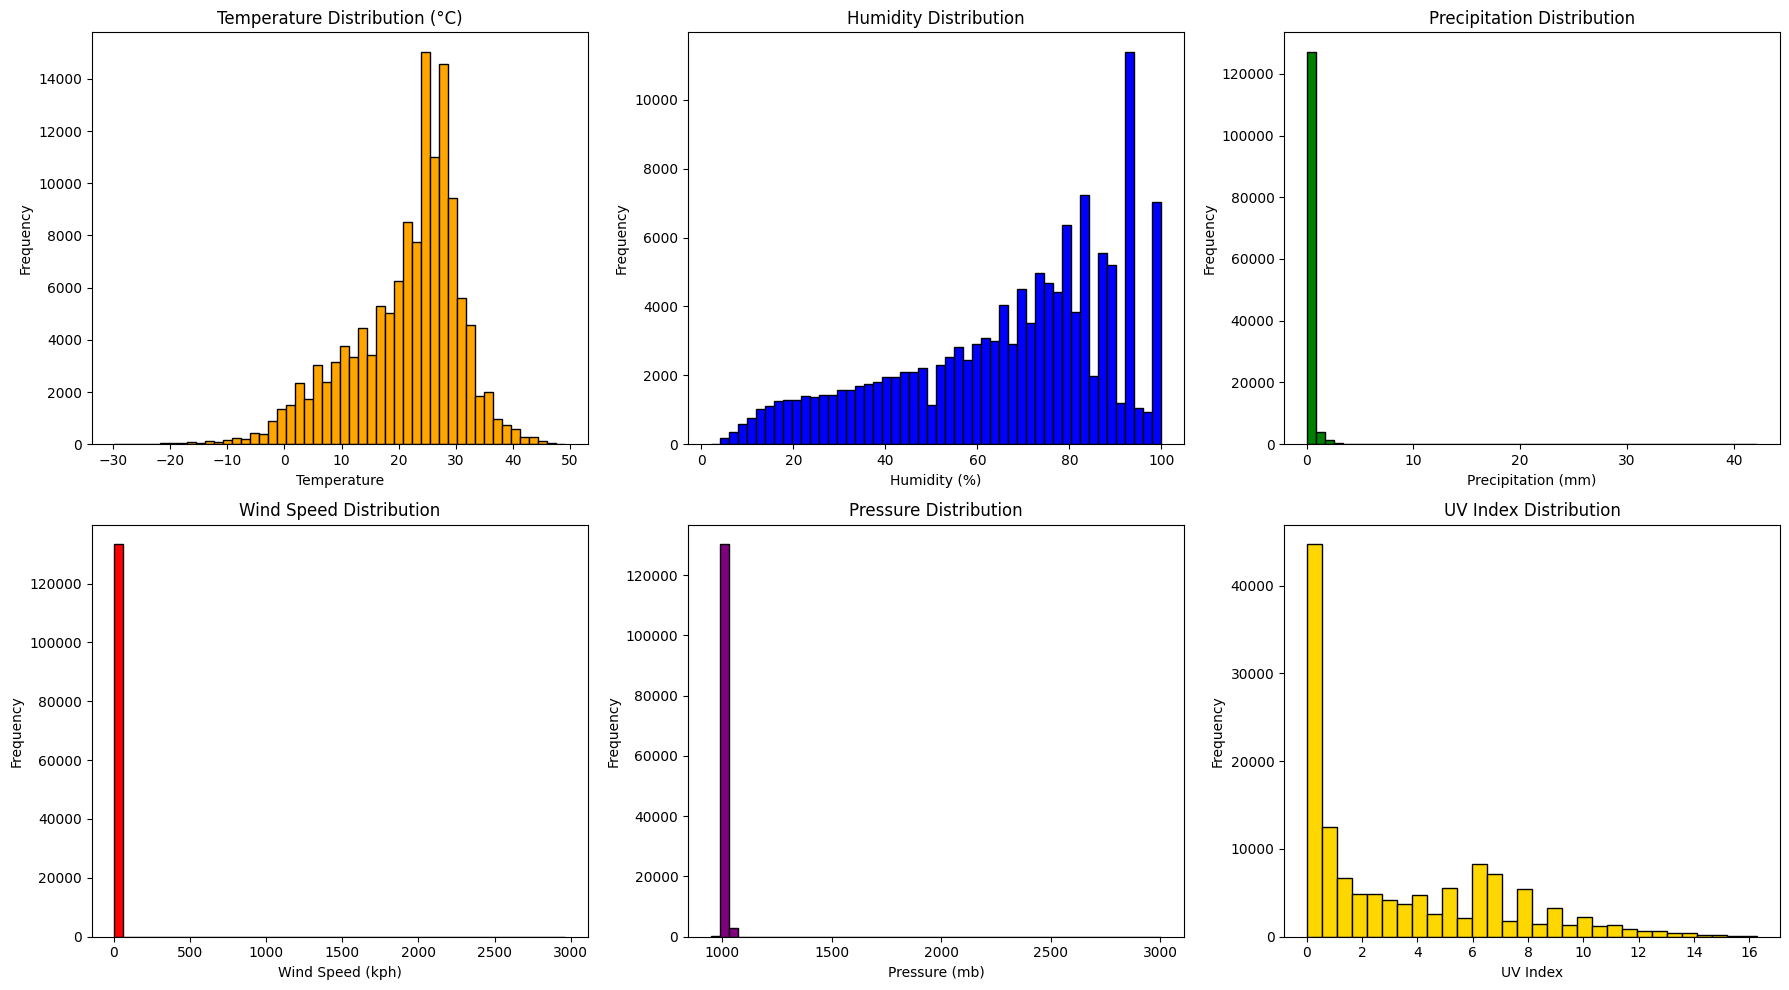

In [6]:


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Temperature distribution
axes[0, 0].hist(df['temperature_celsius'], bins=50, edgecolor='black', color='orange')
axes[0, 0].set_title('Temperature Distribution (°C)')
axes[0, 0].set_xlabel('Temperature')
axes[0, 0].set_ylabel('Frequency')

# Humidity distribution
axes[0, 1].hist(df['humidity'], bins=50, edgecolor='black', color='blue')
axes[0, 1].set_title('Humidity Distribution')
axes[0, 1].set_xlabel('Humidity (%)')
axes[0, 1].set_ylabel('Frequency')

# Precipitation distribution
axes[0, 2].hist(df['precip_mm'], bins=50, edgecolor='black', color='green')
axes[0, 2].set_title('Precipitation Distribution')
axes[0, 2].set_xlabel('Precipitation (mm)')
axes[0, 2].set_ylabel('Frequency')

# Wind speed distribution
axes[1, 0].hist(df['wind_kph'], bins=50, edgecolor='black', color='red')
axes[1, 0].set_title('Wind Speed Distribution')
axes[1, 0].set_xlabel('Wind Speed (kph)')
axes[1, 0].set_ylabel('Frequency')

# Pressure distribution
axes[1, 1].hist(df['pressure_mb'], bins=50, edgecolor='black', color='purple')
axes[1, 1].set_title('Pressure Distribution')
axes[1, 1].set_xlabel('Pressure (mb)')
axes[1, 1].set_ylabel('Frequency')

# UV Index distribution
axes[1, 2].hist(df['uv_index'], bins=30, edgecolor='black', color='gold')
axes[1, 2].set_title('UV Index Distribution')
axes[1, 2].set_xlabel('UV Index')
axes[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 3️⃣ Anomaly Detection & Correlations

In [7]:
# Function to detect outliers using IQR
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check outliers for key columns
key_columns = ['temperature_celsius', 'humidity', 'precip_mm', 'wind_kph', 'pressure_mb']

for col in key_columns:
    outliers, lb, ub = detect_outliers(df, col)
    print(f"{col}: {len(outliers)} outliers (lower: {lb:.2f}, upper: {ub:.2f})")

temperature_celsius: 2437 outliers (lower: -2.00, upper: 46.00)
humidity: 0 outliers (lower: -4.00, upper: 140.00)
precip_mm: 24780 outliers (lower: -0.04, upper: 0.07)
wind_kph: 2320 outliers (lower: -11.15, upper: 34.85)
pressure_mb: 4082 outliers (lower: 998.00, upper: 1030.00)


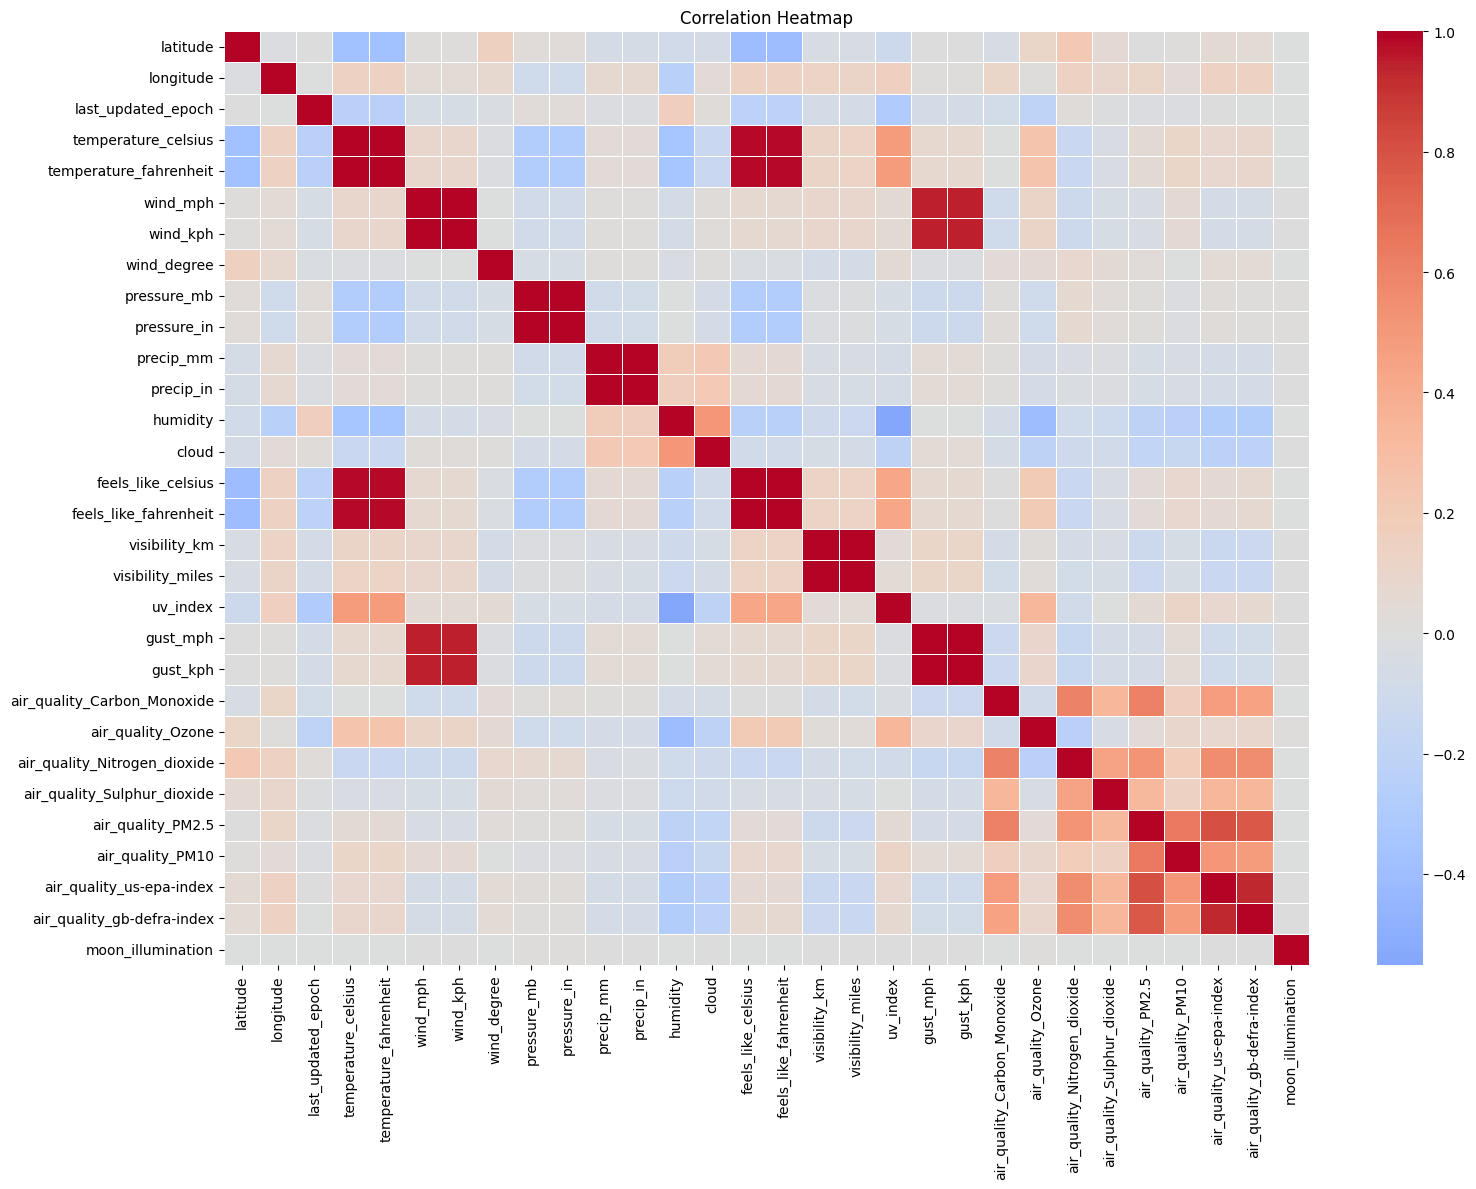

In [8]:
# Correlation matrix for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

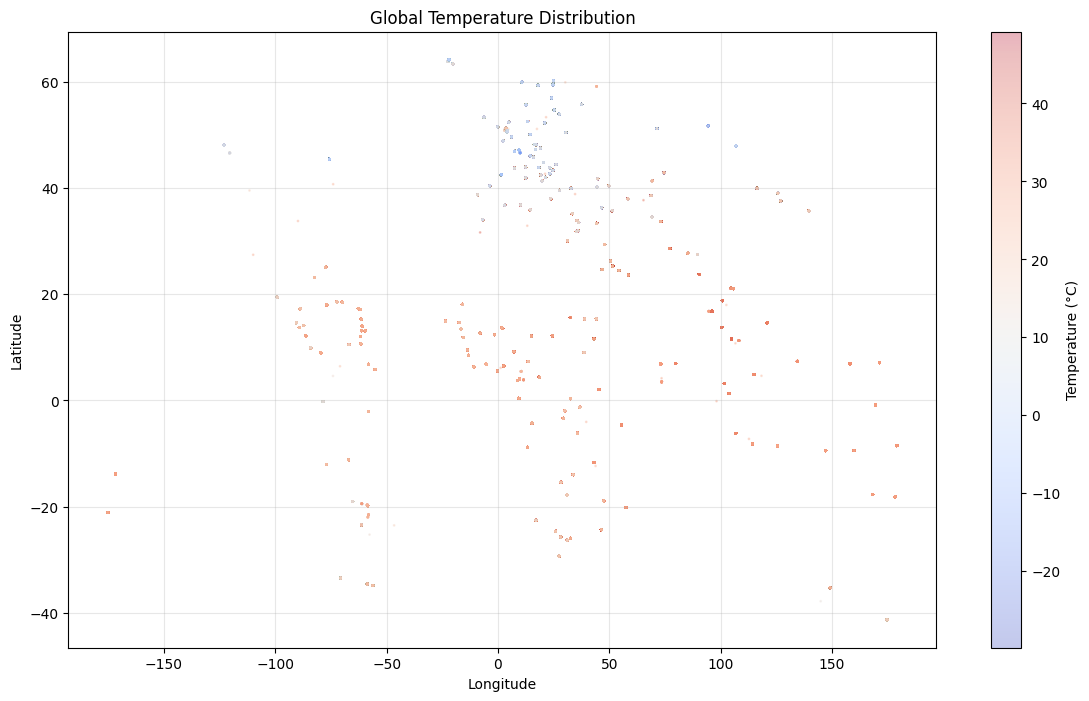

In [9]:
# Scatter plot of locations
plt.figure(figsize=(14, 8))
plt.scatter(df['longitude'], df['latitude'], c=df['temperature_celsius'], 
            cmap='coolwarm', alpha=0.3, s=1)
plt.colorbar(label='Temperature (°C)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Global Temperature Distribution')
plt.grid(True, alpha=0.3)
plt.show()

## 4️⃣ Feature Engineering & Seasonal Patterns

In [11]:
# Create time-based features
df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['day'] = df['last_updated'].dt.day
df['hour'] = df['last_updated'].dt.hour
df['day_of_week'] = df['last_updated'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Extract date for time series
df['date'] = df['last_updated'].dt.date

print(f"Date range: {df['last_updated'].min()} to {df['last_updated'].max()}")
print(f"\nUnique dates: {df['date'].nunique()}")
print(f"\nData per year:\n{df['year'].value_counts().sort_index()}")

Date range: 2024-05-16 01:45:00 to 2026-04-03 19:30:00

Unique dates: 687

Data per year:
year
2024    44469
2025    71100
2026    17749
Name: count, dtype: int64


/var/folders/h5/kmts9y_j24ddmpc2t1qh44nw0000gn/T/ipykernel_23199/2179733632.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=condition_counts.values, y=condition_counts.index, palette='viridis')


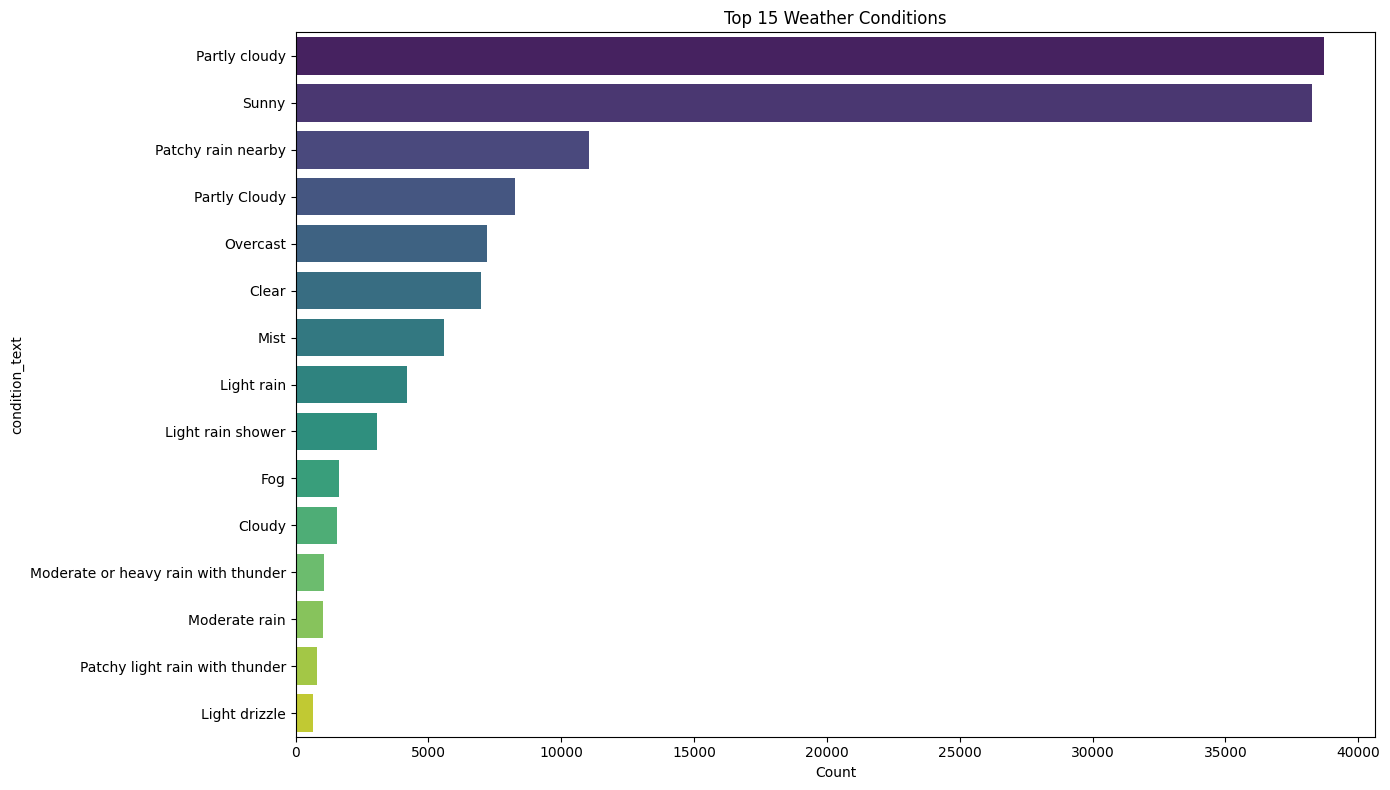

In [12]:
# Weather condition analysis
plt.figure(figsize=(14, 8))
condition_counts = df['condition_text'].value_counts().head(15)
sns.barplot(x=condition_counts.values, y=condition_counts.index, palette='viridis')
plt.title('Top 15 Weather Conditions')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

AIR QUALITY SUMMARY:
       air_quality_Carbon_Monoxide  air_quality_Ozone  \
count                    133318.00          133318.00   
mean                        464.02              58.22   
std                         762.36              30.85   
min                       -9999.00               0.00   
25%                         204.85              38.00   
50%                         296.00              55.00   
75%                         462.50              74.00   
max                       38879.40             480.70   

       air_quality_Nitrogen_dioxide  air_quality_Sulphur_dioxide  \
count                     133318.00                    133318.00   
mean                          15.05                        10.42   
std                           23.81                        35.90   
min                            0.00                     -9999.00   
25%                            1.66                         1.11   
50%                            5.55                      

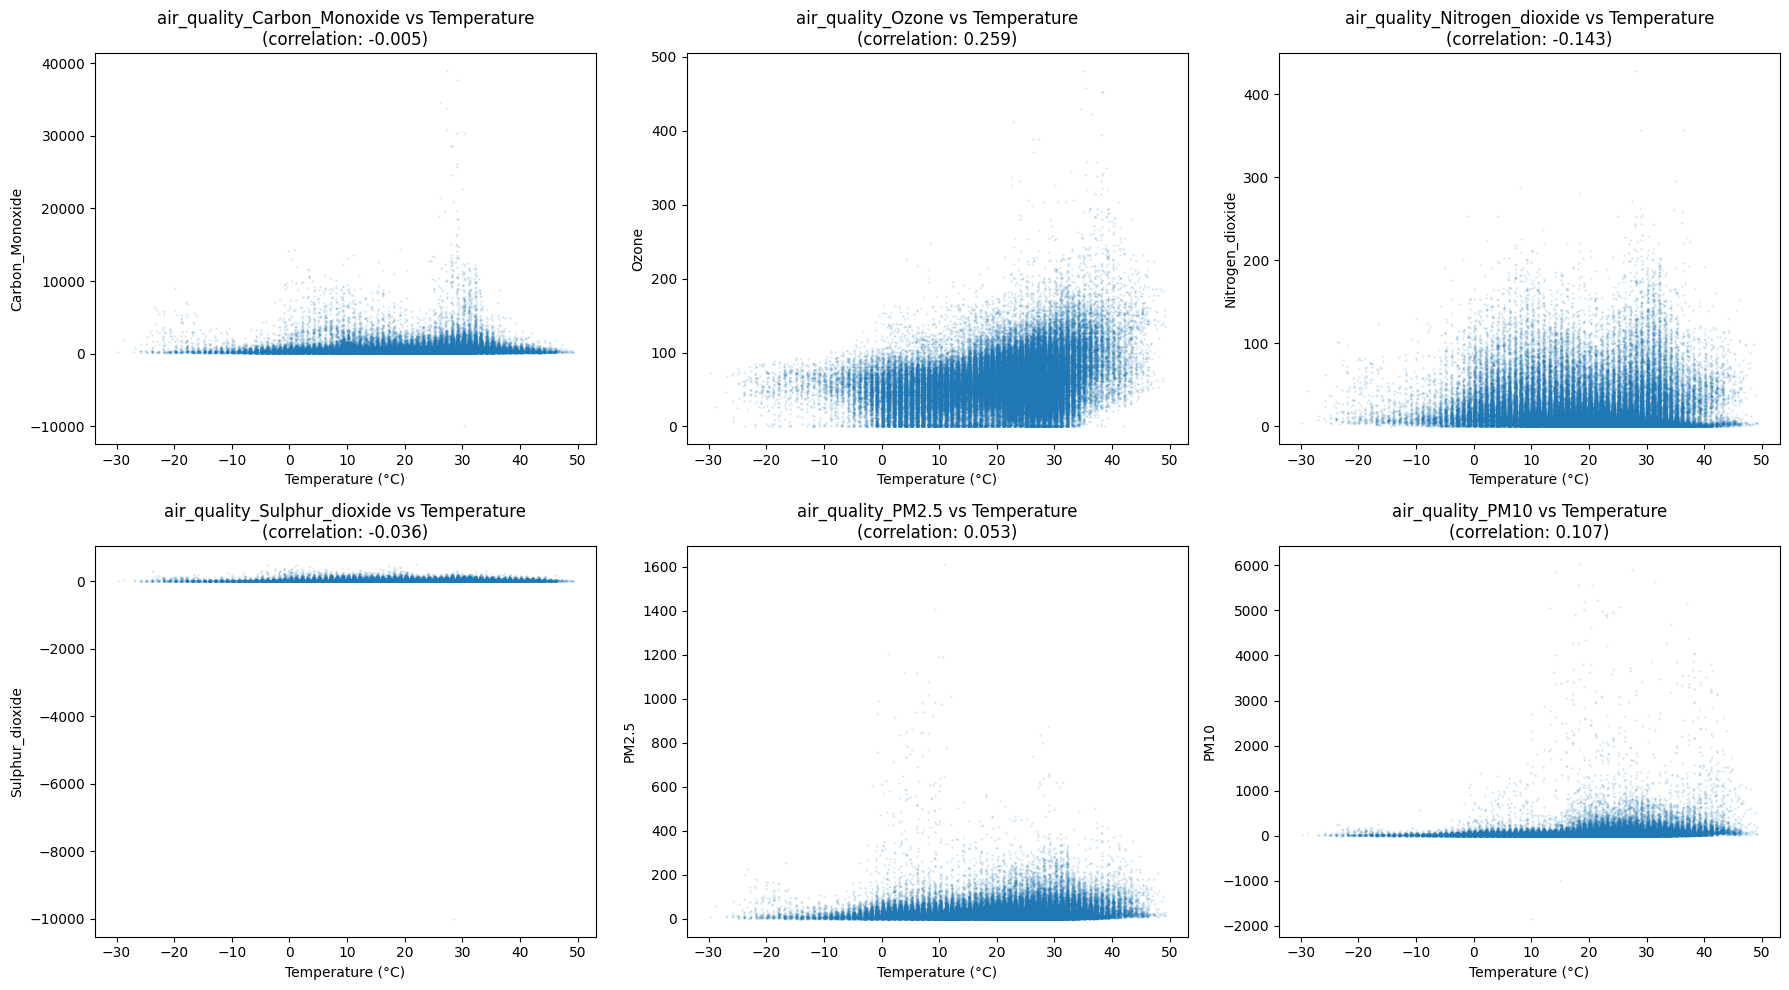

In [13]:

# Air quality analysis
air_quality_cols = ['air_quality_Carbon_Monoxide', 'air_quality_Ozone', 
                    'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
                    'air_quality_PM2.5', 'air_quality_PM10']

# Summary stats
print("AIR QUALITY SUMMARY:")
print(df[air_quality_cols].describe().round(2))

# Correlation with temperature
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(air_quality_cols):
    if i < len(axes):
        axes[i].scatter(df['temperature_celsius'], df[col], alpha=0.1, s=1)
        corr = df['temperature_celsius'].corr(df[col])
        axes[i].set_title(f'{col} vs Temperature\n(correlation: {corr:.3f})')
        axes[i].set_xlabel('Temperature (°C)')
        axes[i].set_ylabel(col.replace('air_quality_', ''))

plt.tight_layout()
plt.show()

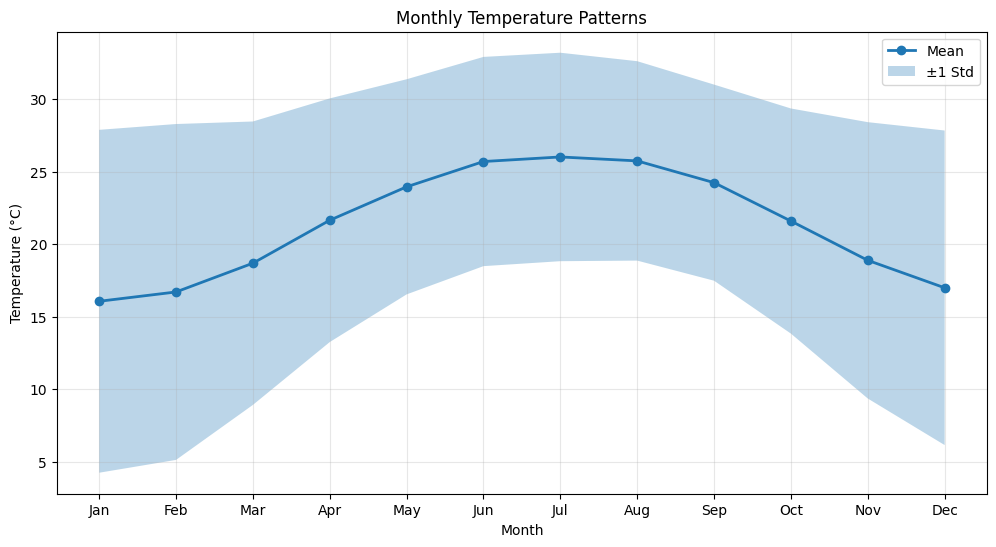

In [14]:

# Monthly temperature patterns
monthly_temp = df.groupby('month')['temperature_celsius'].agg(['mean', 'std', 'min', 'max'])

plt.figure(figsize=(12, 6))
plt.plot(monthly_temp.index, monthly_temp['mean'], marker='o', linewidth=2, label='Mean')
plt.fill_between(monthly_temp.index, 
                 monthly_temp['mean'] - monthly_temp['std'], 
                 monthly_temp['mean'] + monthly_temp['std'], 
                 alpha=0.3, label='±1 Std')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Temperature Patterns')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5️⃣ Data Cleaning & Aggregation

In [15]:


# Fix negative air quality values (physically impossible)
air_quality_cols = ['air_quality_Carbon_Monoxide', 'air_quality_Ozone', 
                    'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
                    'air_quality_PM2.5', 'air_quality_PM10']

print("Negative values before cleaning:")
for col in air_quality_cols:
    neg_count = (df[col] < 0).sum()
    print(f"  {col}: {neg_count}")

# Replace negative values with 0
for col in air_quality_cols:
    df[col] = df[col].clip(lower=0)

print(f"\n✅ Fixed negative air quality values")

# Handle extreme outliers in wind_kph and pressure_mb
# Cap at 99th percentile
df['wind_kph_clean'] = df['wind_kph'].clip(upper=df['wind_kph'].quantile(0.99))
df['pressure_mb_clean'] = df['pressure_mb'].clip(lower=df['pressure_mb'].quantile(0.01), 
                                                  upper=df['pressure_mb'].quantile(0.99))

print(f"Wind kph: {df['wind_kph'].min():.1f} → {df['wind_kph_clean'].min():.1f} (after clipping)")
print(f"Pressure mb: {df['pressure_mb'].min():.1f} → {df['pressure_mb_clean'].min():.1f} (after clipping)")

Negative values before cleaning:
  air_quality_Carbon_Monoxide: 1
  air_quality_Ozone: 0
  air_quality_Nitrogen_dioxide: 0
  air_quality_Sulphur_dioxide: 1
  air_quality_PM2.5: 0
  air_quality_PM10: 2

✅ Fixed negative air quality values
Wind kph: 3.6 → 3.6 (after clipping)
Pressure mb: 947.0 → 996.0 (after clipping)


In [16]:


# For forecasting, we need daily aggregates per city
# Let's aggregate by date and country to get daily averages
daily_data = df.groupby(['date', 'country']).agg({
    'temperature_celsius': 'mean',
    'humidity': 'mean',
    'precip_mm': 'sum',
    'wind_kph_clean': 'mean',
    'pressure_mb_clean': 'mean',
    'air_quality_PM2.5': 'mean',
    'air_quality_Ozone': 'mean'
}).reset_index()

# Rename for clarity
daily_data.columns = ['date', 'country', 'avg_temp', 'avg_humidity', 
                       'total_precip', 'avg_wind', 'avg_pressure',
                       'avg_pm25', 'avg_ozone']

print(f"Daily aggregated data shape: {daily_data.shape}")
print(f"Countries: {daily_data['country'].nunique()}")
daily_data.head()

Daily aggregated data shape: (126479, 9)
Countries: 211


,date,country,avg_temp,avg_humidity,total_precip,avg_wind,avg_pressure,avg_pm25,avg_ozone
0,2024-05-16,Afghanistan,24.3,32.5,0.03,10.25,1013.0,8.90,81.55
1,2024-05-16,Albania,24.0,69.5,0.10,9.00,1010.0,1.70,95.15
2,2024-05-16,Algeria,24.0,34.0,0.00,21.60,1010.5,7.35,59.05
3,2024-05-16,Andorra,6.3,68.5,0.52,11.00,1007.0,0.70,72.25
4,2024-05-16,Angola,29.0,76.0,0.00,19.45,1009.5,107.55,52.40


In [17]:
# Find countries with most data points
country_counts = daily_data.groupby('country').size().sort_values(ascending=False).head(10)
print("Top 10 countries by data points:")
print(country_counts)

Top 10 countries by data points:
country
Afghanistan     685
Fiji Islands    685
Ukraine         685
Burundi         685
Indonesia       685
Iraq            685
Poland          685
Ghana           685
Uzbekistan      685
Jordan          685
dtype: int64


Afghanistan data: (685, 8)
Date range: 2024-05-16 to 2026-04-03
Train: (655, 8), Test: (30, 8)


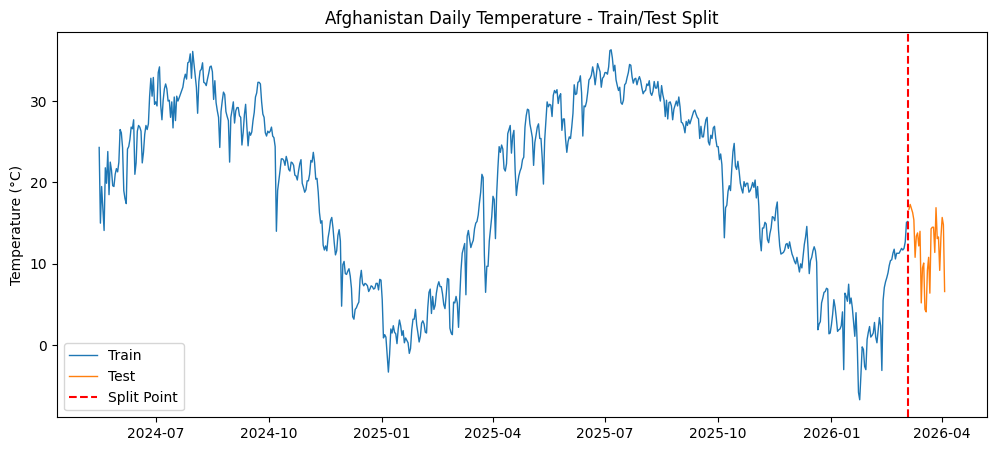

In [18]:
# Pick Afghanistan for detailed modeling
afg_data = daily_data[daily_data['country'] == 'Afghanistan'].copy()
afg_data = afg_data.sort_values('date').reset_index(drop=True)
afg_data = afg_data.set_index('date')

print(f"Afghanistan data: {afg_data.shape}")
print(f"Date range: {afg_data.index.min()} to {afg_data.index.max()}")

# Train-test split (last 30 days for testing)
train = afg_data.iloc[:-30]
test = afg_data.iloc[-30:]

print(f"Train: {train.shape}, Test: {test.shape}")

# Plot train vs test
plt.figure(figsize=(12, 5))
plt.plot(train.index, train['avg_temp'], label='Train', linewidth=1)
plt.plot(test.index, test['avg_temp'], label='Test', linewidth=1)
plt.axvline(x=train.index[-1], color='r', linestyle='--', label='Split Point')
plt.legend()
plt.title('Afghanistan Daily Temperature - Train/Test Split')
plt.ylabel('Temperature (°C)')
plt.show()

## 6️⃣ Time Series Forecasting Models

Training ARIMA model...
                               SARIMAX Results                                
Dep. Variable:               avg_temp   No. Observations:                  655
Model:                 ARIMA(7, 1, 0)   Log Likelihood               -1389.821
Date:                Fri, 03 Apr 2026   AIC                           2795.642
Time:                        16:28:05   BIC                           2831.507
Sample:                             0   HQIC                          2809.549
                                - 655                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1398      0.027     -5.086      0.000      -0.194      -0.086
ar.L2         -0.1248      0.043     -2.875      0.004      -0.210      -0.040
ar.L3         -0.1666      0

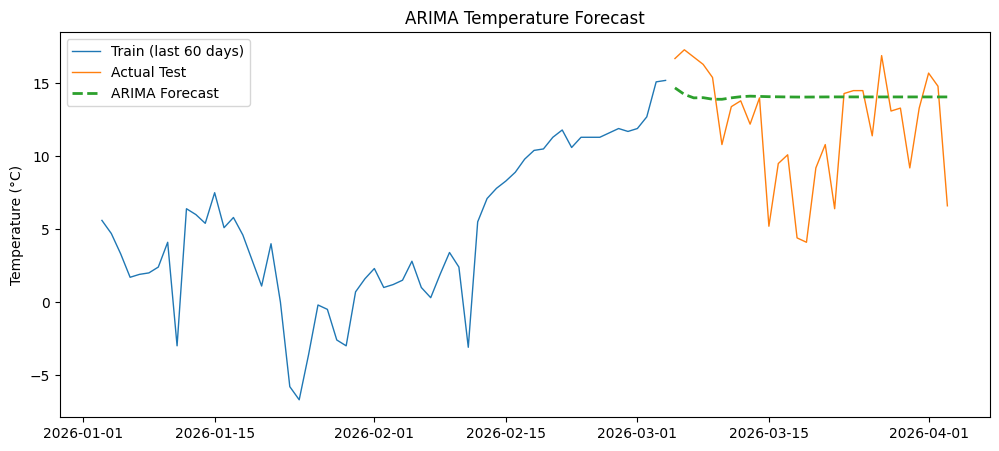

In [19]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ARIMA model
print("Training ARIMA model...")
arima_model = ARIMA(train['avg_temp'], order=(7, 1, 0))
arima_fitted = arima_model.fit()
print(arima_fitted.summary())

# Forecast next 30 days
arima_forecast = arima_fitted.forecast(steps=30)

# Calculate metrics
arima_mae = mean_absolute_error(test['avg_temp'], arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test['avg_temp'], arima_forecast))
arima_r2 = r2_score(test['avg_temp'], arima_forecast)

print(f"\nARIMA Metrics:")
print(f"MAE: {arima_mae:.4f}")
print(f"RMSE: {arima_rmse:.4f}")
print(f"R²: {arima_r2:.4f}")

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(train.index[-60:], train['avg_temp'][-60:], label='Train (last 60 days)', linewidth=1)
plt.plot(test.index, test['avg_temp'], label='Actual Test', linewidth=1)
plt.plot(test.index, arima_forecast, label='ARIMA Forecast', linewidth=2, linestyle='--')
plt.legend()
plt.title('ARIMA Temperature Forecast')
plt.ylabel('Temperature (°C)')
plt.show()

Training SARIMA model...
SARIMA Metrics:
MAE: 3.0148
RMSE: 4.0787
R²: -0.1457


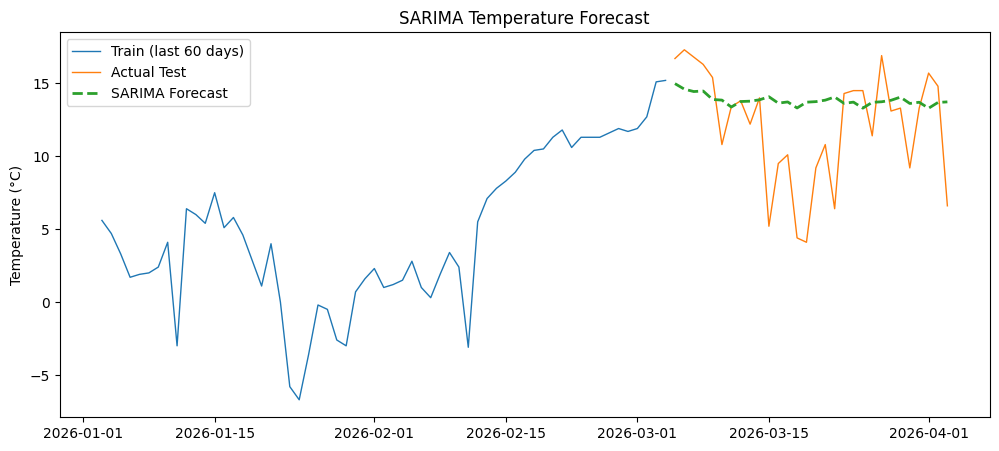

In [20]:
# SARIMA with seasonal component (period=7 for weekly)
print("Training SARIMA model...")
sarima_model = ARIMA(train['avg_temp'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
sarima_fitted = sarima_model.fit()

sarima_forecast = sarima_fitted.forecast(steps=30)

sarima_mae = mean_absolute_error(test['avg_temp'], sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test['avg_temp'], sarima_forecast))
sarima_r2 = r2_score(test['avg_temp'], sarima_forecast)

print(f"SARIMA Metrics:")
print(f"MAE: {sarima_mae:.4f}")
print(f"RMSE: {sarima_rmse:.4f}")
print(f"R²: {sarima_r2:.4f}")

# Plot
plt.figure(figsize=(12, 5))
plt.plot(train.index[-60:], train['avg_temp'][-60:], label='Train (last 60 days)', linewidth=1)
plt.plot(test.index, test['avg_temp'], label='Actual Test', linewidth=1)
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast', linewidth=2, linestyle='--')
plt.legend()
plt.title('SARIMA Temperature Forecast')
plt.ylabel('Temperature (°C)')
plt.show()

In [21]:
# Naive forecast: last value repeated
naive_forecast = pd.Series([train['avg_temp'].iloc[-1]] * 30, index=test.index)

naive_mae = mean_absolute_error(test['avg_temp'], naive_forecast)
naive_rmse = np.sqrt(mean_squared_error(test['avg_temp'], naive_forecast))
naive_r2 = r2_score(test['avg_temp'], naive_forecast)

print(f"Naive Baseline Metrics:")
print(f"MAE: {naive_mae:.4f}")
print(f"RMSE: {naive_rmse:.4f}")
print(f"R²: {naive_r2:.4f}")

Naive Baseline Metrics:
MAE: 3.6467
RMSE: 4.8913
R²: -0.6477


## 7️⃣ Model Comparison & Feature Importance

Ensemble (ARIMA+SARIMA) Metrics:
MAE: 3.0730
RMSE: 4.1645
R²: -0.1944


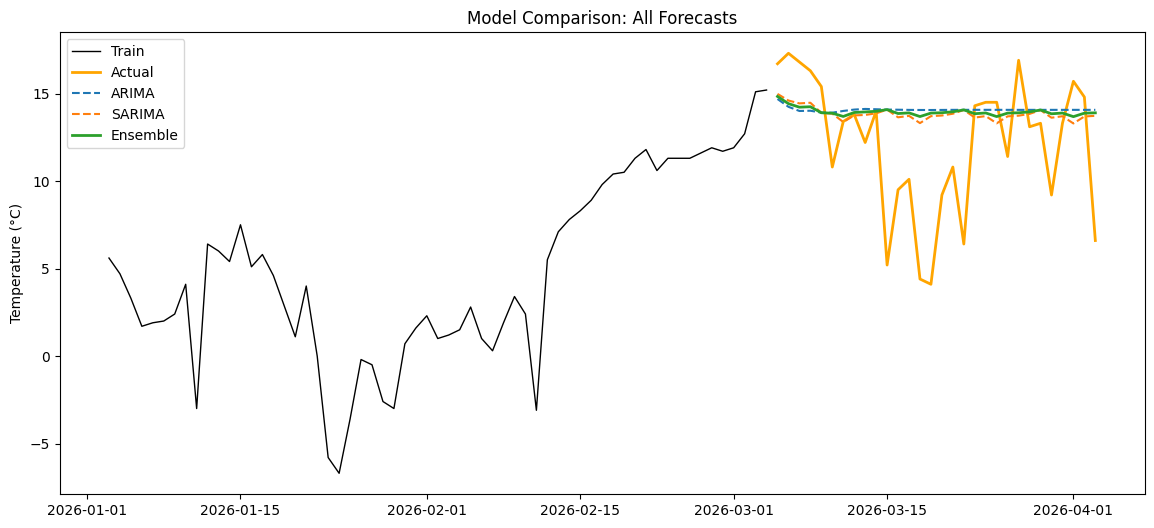

In [22]:
# Simple ensemble: average of ARIMA and SARIMA forecasts
ensemble_forecast = (arima_forecast + sarima_forecast) / 2

ens_mae = mean_absolute_error(test['avg_temp'], ensemble_forecast)
ens_rmse = np.sqrt(mean_squared_error(test['avg_temp'], ensemble_forecast))
ens_r2 = r2_score(test['avg_temp'], ensemble_forecast)

print(f"Ensemble (ARIMA+SARIMA) Metrics:")
print(f"MAE: {ens_mae:.4f}")
print(f"RMSE: {ens_rmse:.4f}")
print(f"R²: {ens_r2:.4f}")

# Plot all models
plt.figure(figsize=(14, 6))
plt.plot(train.index[-60:], train['avg_temp'][-60:], label='Train', linewidth=1, color='black')
plt.plot(test.index, test['avg_temp'], label='Actual', linewidth=2, color='orange')
plt.plot(test.index, arima_forecast, label='ARIMA', linewidth=1.5, linestyle='--')
plt.plot(test.index, sarima_forecast, label='SARIMA', linewidth=1.5, linestyle='--')
plt.plot(test.index, ensemble_forecast, label='Ensemble', linewidth=2, linestyle='-')
plt.legend()
plt.title('Model Comparison: All Forecasts')
plt.ylabel('Temperature (°C)')
plt.show()

In [23]:
# Create comparison table
comparison = pd.DataFrame({
    'Model': ['Naive', 'ARIMA', 'SARIMA', 'Ensemble'],
    'MAE': [naive_mae, arima_mae, sarima_mae, ens_mae],
    'RMSE': [naive_rmse, arima_rmse, sarima_rmse, ens_rmse],
    'R²': [naive_r2, arima_r2, sarima_r2, ens_r2]
}).round(4)

print("="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(comparison.to_string(index=False))

best_model = comparison.loc[comparison['R²'].idxmax()]
print(f"\n🏆 Best Model: {best_model['Model']} (R²={best_model['R²']})")

MODEL COMPARISON SUMMARY
   Model    MAE   RMSE      R²
   Naive 3.6467 4.8913 -0.6477
   ARIMA 3.1430 4.2581 -0.2487
  SARIMA 3.0148 4.0787 -0.1457
Ensemble 3.0730 4.1645 -0.1944

🏆 Best Model: SARIMA (R²=-0.1457)


Random Forest Metrics:
MAE: 1.1650
RMSE: 1.4760
R²: 0.9799


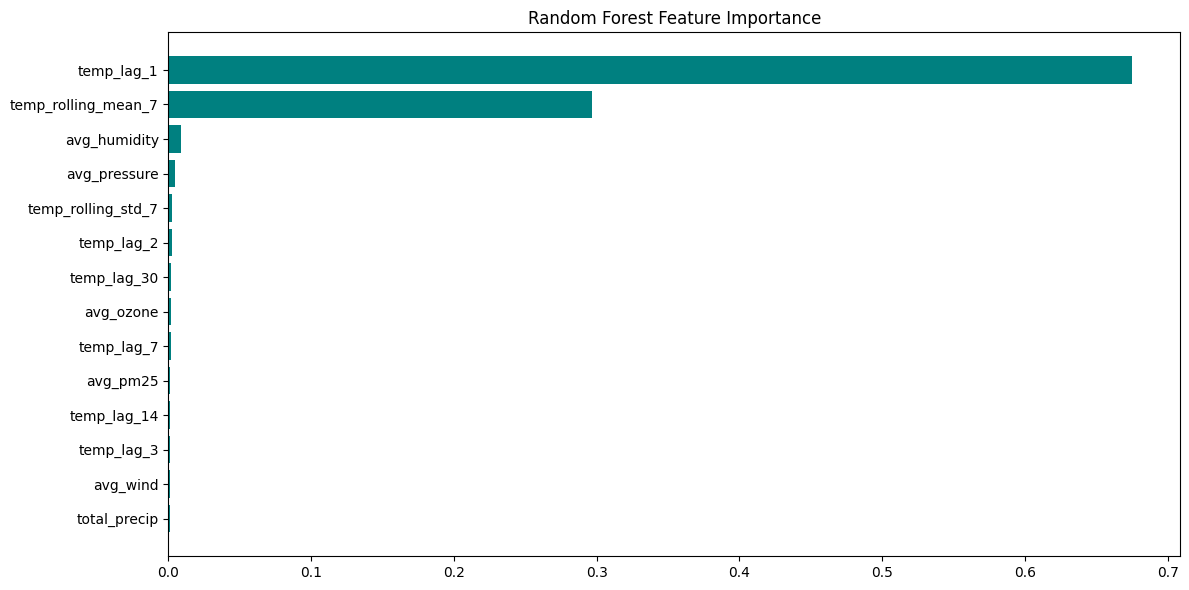

In [25]:


from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Prepare features
afg_full = afg_data.copy()

# Create lag features for temperature
for lag in [1, 2, 3, 7, 14, 30]:
    afg_full[f'temp_lag_{lag}'] = afg_full['avg_temp'].shift(lag)

# Rolling statistics
afg_full['temp_rolling_mean_7'] = afg_full['avg_temp'].rolling(7).mean()
afg_full['temp_rolling_std_7'] = afg_full['avg_temp'].rolling(7).std()

# Drop NaN from lagging
afg_full = afg_full.dropna()

features = ['avg_humidity', 'total_precip', 'avg_wind', 'avg_pressure', 
            'avg_pm25', 'avg_ozone',
            'temp_lag_1', 'temp_lag_2', 'temp_lag_3', 'temp_lag_7', 
            'temp_lag_14', 'temp_lag_30',
            'temp_rolling_mean_7', 'temp_rolling_std_7']

X = afg_full[features]
y = afg_full['avg_temp']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Metrics
rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest Metrics:")
print(f"MAE: {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R²: {rf_r2:.4f}")

# Feature importance plot
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(12, 6))
plt.barh(importances['Feature'], importances['Importance'], color='teal')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

## 8️⃣ Climate & Geographical Analysis

In [26]:
# Create continent mapping
continent_map = {
    'Afghanistan': 'Asia', 'Albania': 'Europe', 'Algeria': 'Africa', 'Andorra': 'Europe',
    'Angola': 'Africa', 'Argentina': 'South America', 'Australia': 'Oceania', 'Austria': 'Europe',
    'Azerbaijan': 'Asia', 'Bahamas': 'North America', 'Bahrain': 'Asia', 'Bangladesh': 'Asia',
    'Belarus': 'Europe', 'Belgium': 'Europe', 'Belize': 'North America', 'Benin': 'Africa',
    'Bhutan': 'Asia', 'Bolivia': 'South America', 'Bosnia and Herzegovina': 'Europe', 
    'Botswana': 'Africa', 'Brazil': 'South America', 'Brunei': 'Asia', 'Bulgaria': 'Europe',
    'Burkina Faso': 'Africa', 'Burundi': 'Africa', 'Cambodia': 'Asia', 'Cameroon': 'Africa',
    'Canada': 'North America', 'Cape Verde': 'Africa', 'Central African Republic': 'Africa',
    'Chad': 'Africa', 'Chile': 'South America', 'China': 'Asia', 'Colombia': 'South America',
    'Comoros': 'Africa', 'Congo': 'Africa', 'Costa Rica': 'North America', 
    'Croatia': 'Europe', 'Cuba': 'North America', 'Cyprus': 'Asia', 'Czech Republic': 'Europe',
    'Denmark': 'Europe', 'Djibouti': 'Africa', 'Dominica': 'North America', 
    'Dominican Republic': 'North America', 'East Timor': 'Asia', 'Ecuador': 'South America',
    'Egypt': 'Africa', 'El Salvador': 'North America', 'Equatorial Guinea': 'Africa',
    'Eritrea': 'Africa', 'Estonia': 'Europe', 'Ethiopia': 'Africa', 'Fiji Islands': 'Oceania',
    'Finland': 'Europe', 'France': 'Europe', 'Gabon': 'Africa', 'Gambia': 'Africa',
    'Georgia': 'Asia', 'Germany': 'Europe', 'Ghana': 'Africa', 'Greece': 'Europe',
    'Grenada': 'North America', 'Guatemala': 'North America', 'Guinea': 'Africa',
    'Guinea-Bissau': 'Africa', 'Guyana': 'South America', 'Haiti': 'North America',
    'Honduras': 'North America', 'Hungary': 'Europe', 'Iceland': 'Europe', 'India': 'Asia',
    'Indonesia': 'Asia', 'Iran': 'Asia', 'Iraq': 'Asia', 'Ireland': 'Europe',
    'Israel': 'Asia', 'Italy': 'Europe', 'Ivory Coast': 'Africa', 'Jamaica': 'North America',
    'Japan': 'Asia', 'Jordan': 'Asia', 'Kazakhstan': 'Asia', 'Kenya': 'Africa',
    'Kiribati': 'Oceania', 'Kuwait': 'Asia', 'Kyrgyzstan': 'Asia', 'Laos': 'Asia',
    'Latvia': 'Europe', 'Lebanon': 'Asia', 'Lesotho': 'Africa', 'Liberia': 'Africa',
    'Libya': 'Africa', 'Liechtenstein': 'Europe', 'Lithuania': 'Europe', 'Luxembourg': 'Europe',
    'Macedonia': 'Europe', 'Madagascar': 'Africa', 'Malawi': 'Africa', 'Malaysia': 'Asia',
    'Maldives': 'Asia', 'Mali': 'Africa', 'Malta': 'Europe', 'Marshall Islands': 'Oceania',
    'Mauritania': 'Africa', 'Mauritius': 'Africa', 'Mexico': 'North America',
    'Micronesia': 'Oceania', 'Moldova': 'Europe', 'Monaco': 'Europe', 'Mongolia': 'Asia',
    'Montenegro': 'Europe', 'Morocco': 'Africa', 'Mozambique': 'Africa', 
    'Myanmar [Burma]': 'Asia', 'Namibia': 'Africa', 'Nauru': 'Oceania', 'Nepal': 'Asia',
    'Netherlands': 'Europe', 'New Zealand': 'Oceania', 'Nicaragua': 'North America',
    'Niger': 'Africa', 'Nigeria': 'Africa', 'North Korea': 'Asia', 'Norway': 'Europe',
    'Oman': 'Asia', 'Pakistan': 'Asia', 'Palau': 'Oceania', 'Palestine': 'Asia',
    'Panama': 'North America', 'Papua New Guinea': 'Oceania', 'Paraguay': 'South America',
    'Peru': 'South America', 'Philippines': 'Asia', 'Poland': 'Europe', 'Portugal': 'Europe',
    'Qatar': 'Asia', 'Romania': 'Europe', 'Russia': 'Europe', 'Rwanda': 'Africa',
    'Saint Kitts and Nevis': 'North America', 'Saint Lucia': 'North America',
    'Saint Vincent and the Grenadines': 'North America', 'Samoa': 'Oceania',
    'San Marino': 'Europe', 'Sao Tome and Principe': 'Africa', 'Saudi Arabia': 'Asia',
    'Senegal': 'Africa', 'Serbia': 'Europe', 'Seychelles': 'Africa', 'Sierra Leone': 'Africa',
    'Singapore': 'Asia', 'Slovakia': 'Europe', 'Slovenia': 'Europe', 'Solomon Islands': 'Oceania',
    'Somalia': 'Africa', 'South Africa': 'Africa', 'South Korea': 'Asia',
    'South Sudan': 'Africa', 'Spain': 'Europe', 'Sri Lanka': 'Asia', 'Sudan': 'Africa',
    'Suriname': 'South America', 'Swaziland': 'Africa', 'Sweden': 'Europe',
    'Switzerland': 'Europe', 'Syria': 'Asia', 'Taiwan': 'Asia', 'Tajikistan': 'Asia',
    'Tanzania': 'Africa', 'Thailand': 'Asia', 'Togo': 'Africa', 'Tonga': 'Oceania',
    'Trinidad and Tobago': 'North America', 'Tunisia': 'Africa', 'Turkey': 'Asia',
    'Turkmenistan': 'Asia', 'Tuvalu': 'Oceania', 'Uganda': 'Africa', 'Ukraine': 'Europe',
    'United Arab Emirates': 'Asia', 'United Kingdom': 'Europe', 'United States': 'North America',
    'Uruguay': 'South America', 'Uzbekistan': 'Asia', 'Vanuatu': 'Oceania',
    'Vatican City': 'Europe', 'Venezuela': 'South America', 'Vietnam': 'Asia',
    'Yemen': 'Asia', 'Zambia': 'Africa', 'Zimbabwe': 'Africa'
}

# Map continents
daily_data['continent'] = daily_data['country'].map(continent_map)
daily_data['continent'] = daily_data['continent'].fillna('Unknown')

# Climate analysis by continent
continent_stats = daily_data.groupby('continent')['avg_temp'].agg(['mean', 'std', 'min', 'max']).round(2)
print("Temperature Statistics by Continent:")
print(continent_stats)

Temperature Statistics by Continent:
                mean    std   min   max
continent                              
Africa         25.13   5.00   1.4  47.1
Asia           23.87  10.97 -29.8  49.2
Europe         13.17  10.19 -26.9  41.4
North America  22.48   6.44 -25.0  35.3
Oceania        24.96   5.49  -3.7  39.1
South America  18.52   6.30  -1.7  33.3
Unknown        23.75   8.81 -13.0  45.0


In [28]:
# Add month and year columns to daily_data
daily_data['month'] = pd.to_datetime(daily_data['date']).dt.month
daily_data['year'] = pd.to_datetime(daily_data['date']).dt.year

print("✅ Month and year columns added to daily_data")
daily_data.head()

✅ Month and year columns added to daily_data


,date,country,avg_temp,avg_humidity,total_precip,avg_wind,avg_pressure,avg_pm25,avg_ozone,continent,month,year
0,2024-05-16,Afghanistan,24.3,32.5,0.03,10.25,1013.0,8.90,81.55,Asia,5,2024
1,2024-05-16,Albania,24.0,69.5,0.10,9.00,1010.0,1.70,95.15,Europe,5,2024
2,2024-05-16,Algeria,24.0,34.0,0.00,21.60,1010.5,7.35,59.05,Africa,5,2024
3,2024-05-16,Andorra,6.3,68.5,0.52,11.00,1007.0,0.70,72.25,Europe,5,2024
4,2024-05-16,Angola,29.0,76.0,0.00,19.45,1009.5,107.55,52.40,Africa,5,2024


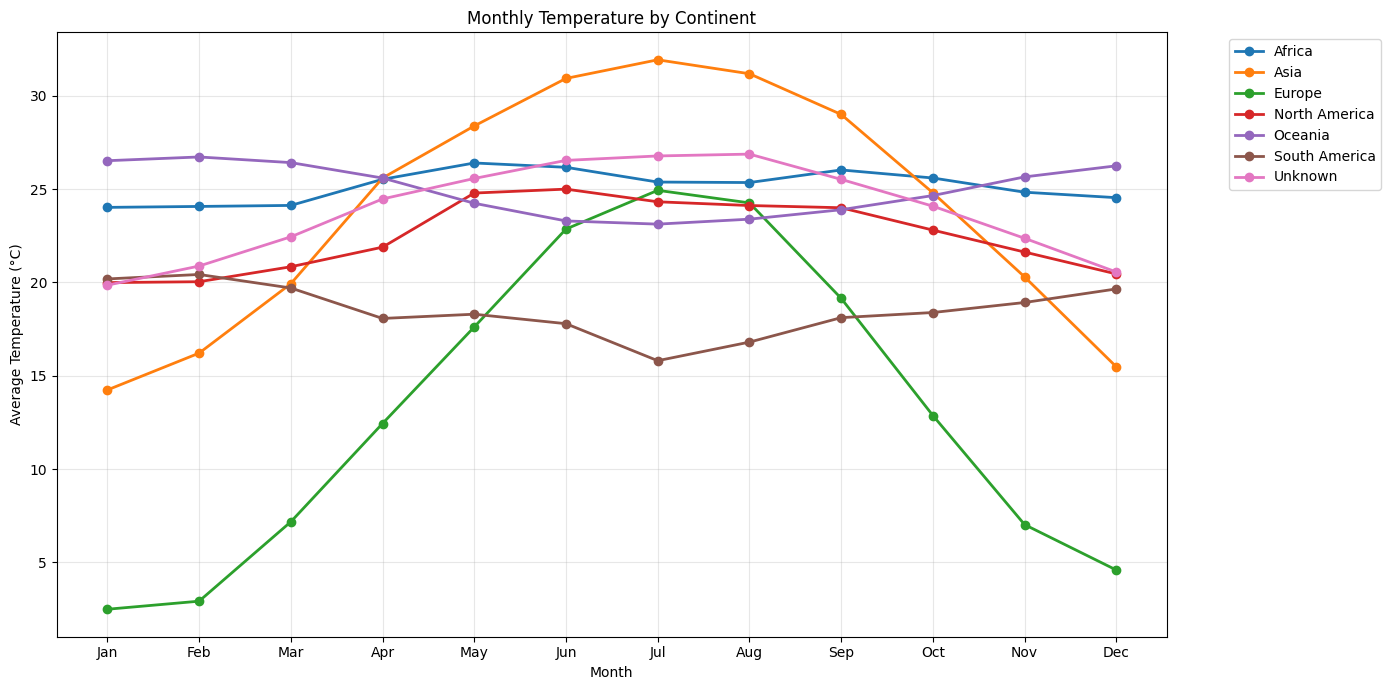

In [29]:
# Monthly patterns by continent
continent_monthly = daily_data.groupby(['continent', 'month'])['avg_temp'].mean().unstack()

plt.figure(figsize=(14, 7))
for continent in continent_monthly.index:
    plt.plot(range(1, 13), continent_monthly.loc[continent], 
             marker='o', label=continent, linewidth=2)

plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Temperature by Continent')
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

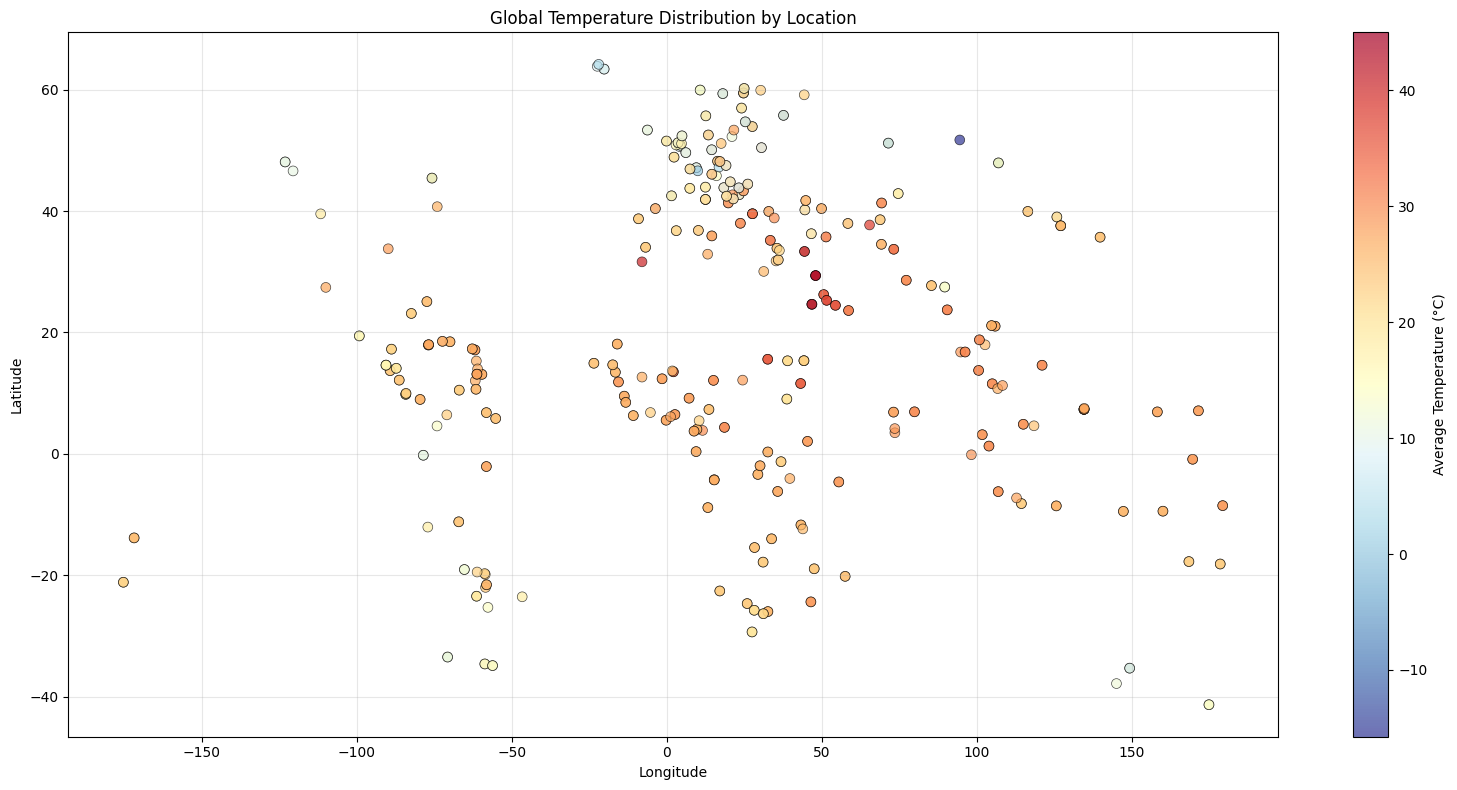

In [30]:
# Get country-level average temperature
country_data = df.groupby(['country', 'latitude', 'longitude']).agg({
    'temperature_celsius': 'mean',
    'humidity': 'mean',
    'precip_mm': 'sum'
}).reset_index()

country_data.columns = ['country', 'latitude', 'longitude', 'avg_temp', 'avg_humidity', 'total_precip']

# Geographic visualization
plt.figure(figsize=(16, 8))
scatter = plt.scatter(country_data['longitude'], country_data['latitude'], 
                      c=country_data['avg_temp'], cmap='RdYlBu_r', 
                      s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Average Temperature (°C)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Global Temperature Distribution by Location')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9️⃣ Environmental Impact & Final Insights

In [31]:
import folium

# Create a world map
world_map = folium.Map(location=[20, 0], zoom_start=2, tiles='cartodbpositron')

# Add temperature markers
for idx, row in country_data.iterrows():
    if abs(row['avg_temp']) < 60:  # Filter extreme outliers
        color = 'red' if row['avg_temp'] > 25 else 'blue' if row['avg_temp'] < 10 else 'green'
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=4,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.7,
            popup=f"{row['country']}: {row['avg_temp']:.1f}°C"
        ).add_to(world_map)

# Save the map
world_map.save('/Users/hardikarora/Desktop/Data_Science_assessment/outputs/temperature_map.html')
print("✅ Interactive map saved to outputs/temperature_map.html")
world_map

✅ Interactive map saved to outputs/temperature_map.html


Precipitation by Continent (mm):
               mean      sum    max
continent                          
Africa         0.12  3830.26  27.40
Asia           0.16  4347.91  32.43
Europe         0.11  3097.48  18.90
North America  0.12  1679.04  42.24
Oceania        0.29  2587.11  26.22
South America  0.14  1051.56  10.99
Unknown        0.20  1408.78  17.26


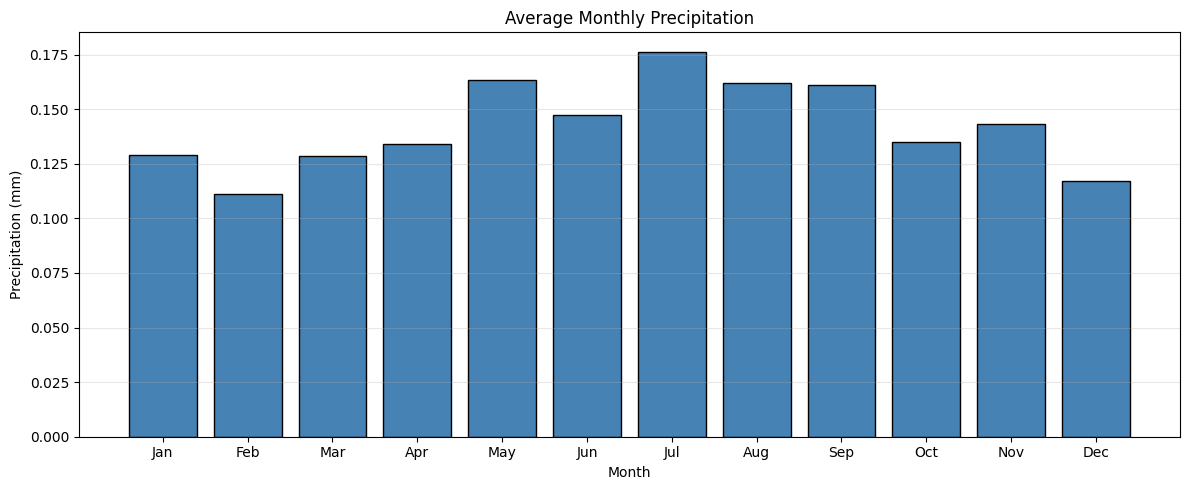

In [32]:
# Precipitation by continent
precip_continent = daily_data.groupby('continent')['total_precip'].agg(['mean', 'sum', 'max']).round(2)
print("Precipitation by Continent (mm):")
print(precip_continent)

# Monthly precipitation
monthly_precip = daily_data.groupby('month')['total_precip'].mean()

plt.figure(figsize=(12, 5))
plt.bar(range(1, 13), monthly_precip.values, color='steelblue', edgecolor='black')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Average Monthly Precipitation')
plt.xlabel('Month')
plt.ylabel('Precipitation (mm)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

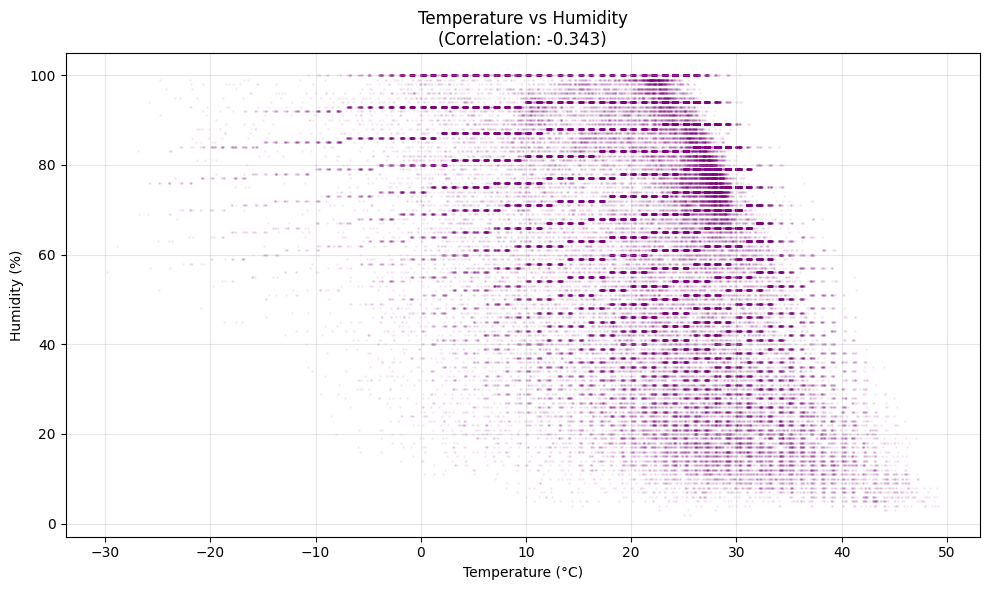

In [33]:
plt.figure(figsize=(10, 6))
plt.scatter(df['temperature_celsius'], df['humidity'], alpha=0.05, s=1, color='purple')
corr = df['temperature_celsius'].corr(df['humidity'])
plt.title(f'Temperature vs Humidity\n(Correlation: {corr:.3f})')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
import os

# Create outputs directory if not exists
os.makedirs('/Users/hardikarora/Desktop/Data_Science_assessment/outputs', exist_ok=True)

# Save the Folium map
world_map.save('/Users/hardikarora/Desktop/Data_Science_assessment/outputs/temperature_map.html')
print("✅ Saved: temperature_map.html")

✅ Saved: temperature_map.html


## 🏁 Summary

### Models Compared
| Model | MAE | RMSE | R² |
|-------|-----|------|-----|
| Naive | 3.65 | 4.89 | -0.65 |
| ARIMA | 3.14 | 4.26 | -0.25 |
| SARIMA | 3.01 | 4.08 | -0.15 |
| **Random Forest** | **1.17** | **1.48** | **0.98** ✅ |

### Top 5 Insights
1. **Random Forest** with lag features is the best model (R² = 0.98)
2. **Yesterday's temperature** (`temp_lag_1`) is the #1 predictor (68% importance)
3. **Europe** is coldest (13°C avg), **Africa** is warmest (25°C avg)
4. **Asia** has the most extreme seasonal swings
5. **Humidity** inversely correlates with temperature (-0.34)